# **01 Knapsack Problem:**

# 問題描述

Welcome to a world invaded by an apocalyptic virus. You are a survivor. Your goal is to survive as long as possible in this chaotic world. You have found an abandoned warehouse filled with various supplies. Your only tool is a specially designed backpack, and its maximum load capacity is only 100 kilograms.

There are 50 types of supplies in the warehouse. Each item has its own survival value and actual weight. Your task is to choose some of these 50 items and put them into your backpack, such that the total survival value you carry is maximized, while the total weight does not exceed 100 kilograms.

This is a classic 01 Knapsack Problem. We will use two algorithms to assist your decision-making:

Simulated Annealing (Simulated Annealing, SA)

Quantum-Inspired Simulated Annealing (Quantum-Inspired Simulated Annealing, SQA).

In [ ]:
!pip install dimod
!pip install dwave-ocean-sdk
!pip install qiskit
!pip install openjij

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 26.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.0
    Uninstalling scipy-1.16.0:
      Successfully uninstalled scipy-1.16.0


# Supplies List and Backpack Configuration

To make the mission full of challenges, we designed a list of 50 types of supplies whose value-to-weight ratios are extremely close. Every choice is directly related to your survival, and you must carefully weigh each decision.

In [ ]:
import numpy as np
import dimod
from IPython.display import display, Math

# Set the maximum backpack weight capacity (unit: kilograms)
MAX_WEIGHT = 100

# Number of items
num_items = 50

# Apocalypse supplies list: (item name, survival value, weight)
# The value-to-weight ratios have been finely adjusted to make the optimal solution less obvious
items_data = [
    ("Water Purifier", 25, 20), ("Solar Charger", 24, 19), ("Antibiotics", 27, 22), ("Compass", 21, 18), ("Map", 26, 21),
    ("Survival Knife", 22, 19), ("Two-way Radio", 28, 23), ("Flashlight", 25, 20), ("Lighter", 30, 25), ("Rope", 20, 17),
    ("First Aid Kit", 28, 24), ("Canned Food", 26, 22), ("High-Energy Compressed Biscuits", 25, 21), ("Waterproof Matches", 30, 26), ("Water Purification Tablets", 27, 23),
    ("Cold-Weather Clothing", 26, 22), ("Sleeping Bag", 24, 20), ("Tent", 28, 24), ("Protective Mask", 25, 21), ("Gas Mask", 23, 20),
    ("Ammunition", 29, 25), ("Firearm", 30, 26), ("Binoculars", 32, 28), ("Night Vision Goggles", 31, 27), ("Generator", 27, 23),
    ("Gasoline", 29, 25), ("Batteries", 30, 26), ("Shovel", 26, 22), ("Axe", 30, 26), ("Nails", 28, 24),
    ("Bandages", 20, 18), ("Disinfectant", 21, 19), ("Suture Kit", 23, 21), ("Painkillers", 19, 17), ("Vitamins", 22, 20),
    ("Fuel Oil", 18, 16), ("Stove", 24, 22), ("Tableware", 16, 15), ("Cookware", 17, 16), ("Raincoat", 23, 21),
    ("Salt", 17, 15), ("Sugar", 15, 14), ("Flour", 13, 12), ("Coffee Beans", 18, 17), ("Cigarettes", 16, 15),
    ("Alcohol", 15, 14), ("Atlas", 17, 16), ("Radio", 14, 13), ("Notebook", 12, 11), ("Pencil", 12, 11)
]

names = [item[0] for item in items_data]
values = np.array([item[1] for item in items_data])
weights = np.array([item[2] for item in items_data)

# Converting the Knapsack Problem into a Mathematical Model

Your ultimate goal is to maximize the total survival value, therefore the problem is transformed into minimizing the “negative total survival value”. At the same time, the weight limit of your backpack becomes a strict penalty term. If the weight limit is exceeded, you will not be able to leave with these supplies.

We define a binary variable x_i to represent whether the i-th type of supply is taken (x_i=1 indicates taken, x_i=0 indicates not taken).

# The Objective Function Can Be Written As:

$$
H(x) = -\sum_{i=1}^N v_i x_i + \lambda \left( \sum_{i=1}^N w_i x_i - C \right)^2
$$

After expansion:

$$
H(x)
= \sum_{i=1}^N \bigl(-v_i + \lambda w_i^2 - 2\lambda C\,w_i\bigr) x_i
\;+\;\sum_{1\le i<j\le N} \bigl(2\lambda\,w_i\,w_j\bigr)\,x_i x_j
\;+\;\lambda C^2.
$$


Where:

- $x = (x_1, x_2, \dots, x_N) \in \{0, 1\}^N$：the binary selection vector representing the choice of supplies  
- $\mathbf{v} = (v_1, v_2, \dots, v_N)$：the survival value vector of each item  
- $\mathbf{w} = (w_1, w_2, \dots, w_N)$：the weight vector of each item  
- $C$：the maximum weight capacity of the backpack  
- $\lambda$：the penalty coefficient used to prevent overweight situations

# Part I: Using Simulated Annealing (Simulated Annealing, SA)

SA is a heuristic algorithm based on the physical annealing process. Imagine a piece of metal that is heated and then gradually cooled. Its molecules transition from a random arrangement toward an ordered crystalline structure, eventually reaching a stable state with minimum energy. SA mimics this process: it starts from a random solution, and at a higher “temperature”, it accepts worse solutions (higher energy) with a certain probability, which helps the algorithm escape the trap of local optima. As the “temperature” gradually decreases, the probability of accepting worse solutions also decreases, and the algorithm eventually converges to a better solution.

In [ ]:
# Solution 1

from dimod import SimulatedAnnealingSampler
import time

# Penalty coefficient, needs to be tuned to find the optimal solution
penalty = 20

# Construct the objective function
model = dimod.BinaryQuadraticModel(dimod.BINARY)

# Negative total value term
for i in range(num_items):
    model.add_variable(i, -values[i])

# Penalty term for the weight constraint (w_i * x_i - C)^2
for i in range(num_items):
    model.add_variable(i, penalty * (weights[i]**2))
    for j in range(i + 1, num_items):
        model.add_interaction(i, j, 2 * penalty * weights[i] * weights[j])

# Subtract 2 * C * (sum w_i * x_i)
for i in range(num_items):
    model.add_variable(i, -2 * penalty * MAX_WEIGHT * weights[i])

# Finally add C^2
model.add_offset(penalty * (MAX_WEIGHT**2))

# Solve using SA
sampler_sa = SimulatedAnnealingSampler()
start_time_sa = time.time()
sampleset_sa = sampler_sa.sample(model, num_reads=100)
end_time_sa = time.time()

best_solution_sa = sampleset_sa.first.sample
selected_indices_sa = [i for i, x in best_solution_sa.items() if x == 1]
selected_names_sa = [names[i] for i in selected_indices_sa]
total_value_sa = sum(values[i] for i in selected_indices_sa)
total_weight_sa = sum(weights[i] for i in selected_indices_sa)

print("--- Simulated Annealing (SA) Supplies List ---")
print(f"Final selected supplies: {selected_names_sa}")
print(f"Total survival value: {total_value_sa}")
print(f"Total weight: {total_weight_sa}")
print(f"Time spent to find this solution: {end_time_sa - start_time_sa:.4f} seconds")
print("---------------------------------")

/tmp/ipython-input-4182232638.py:25: DeprecationWarning: BinaryQuadraticModel.add_offset(bias) is deprecated since dimod 0.10.0 and will be removed in 0.12.0. Please use bqm.offset += bias.
  model.add_offset(penalty * (MAX_WEIGHT**2))


--- 模擬退火 (SA) 物資清單 ---
最終的物資組合： ['斧頭', '縫合針線', '餐具', '鹽', '麵粉', '鉛筆']
總生存價值： 111
總重量： 100
找到這個解花了： 152.5253 秒
---------------------------------


In [ ]:
# Solution 2

# -*- coding: utf-8 -*-
import numpy as np
import dimod
import time

# 0. Problem data (given)
values     = np.array([25,24,27,21,26,22,28,25,30,20,28,26,25,30,27,26,24,28,25,23,
                       29,30,32,31,27,29,30,26,30,28,20,21,23,19,22,18,24,16,17,23,
                       17,15,13,18,16,15,17,14,12,12])
weights    = np.array([20,19,22,18,21,19,23,20,25,17,24,22,21,26,23,22,20,24,21,20,
                       25,26,28,27,23,25,26,22,26,24,18,19,21,17,20,16,22,15,16,21,
                       15,14,12,17,15,14,16,13,11,11])
MAX_WEIGHT = 100
penalty    = 20

# 1. QUBO function
def knapsack_qubo(v, w, C, lam):
    N = len(v)
    Q = {}
    # Linear term h_i = -v_i + λ w_i^2 - 2λ C w_i
    for i in range(N):
        Q[(i,i)] = -v[i] + lam*(w[i]**2) - 2*lam*C*w[i]
    # Interaction term J_{ij} = 2λ w_i w_j
    for i in range(N):
        for j in range(i+1, N):
            Q[(i,j)] = 2*lam*w[i]*w[j]
    offset = lam * (C**2)
    return Q, offset

# 2. Generate QUBO and build BQM
Q, offset = knapsack_qubo(values, weights, MAX_WEIGHT, penalty)
bqm = dimod.BinaryQuadraticModel.from_qubo(Q, offset=offset)

# 3. Solve using Simulated Annealing (SA)
sa_sampler = dimod.SimulatedAnnealingSampler()
start_time = time.time()
sa_result  = sa_sampler.sample(bqm, num_reads=100)
end_time   = time.time()

# 4. Parse results
best_solution      = sa_result.first.sample
selected_indices   = [i for i, x in best_solution.items() if x == 1]
selected_names     = [f"item_{i}" for i in selected_indices]  # or replace with actual names
total_value        = sum(values[i]  for i in selected_indices)
total_weight       = sum(weights[i] for i in selected_indices)

# 5. Print results (same format as Solution 1)
print("--- Simulated Annealing (SA) Supplies List ---")
print(f"Final selected supplies: {selected_names}")
print(f"Total survival value: {total_value}")
print(f"Total weight: {total_weight}")
print(f"Time spent to find this solution: {end_time - start_time:.4f} seconds")
print("---------------------------------")

--- 模擬退火 (SA) 物資清單 ---
最終的物資組合： ['item_40', 'item_41', 'item_42', 'item_43', 'item_44', 'item_46', 'item_48']
總生存價值： 108
總重量： 100
找到這個解花了： 148.3520 秒
---------------------------------


1. Strategy and Results

Observe the set of supplies found by SA. What do you think its selection logic is? Does it tend to choose items with high value but also high weight, or items with a better value-to-weight ratio?

Try adjusting the penalty coefficient penalty. If penalty is set too high, you will become very conservative and only dare to take lightweight items; if it is set too low, you may end up being unable to escape due to exceeding the weight limit. Which penalty value do you think best fits your survival style? Try adjusting it and see!

# Part II: Using Quantum-Inspired Simulated Annealing (SQA)

In classical Simulated Annealing (SA), the algorithm relies solely on “thermal fluctuations” to cross energy barriers, and it often becomes trapped in local minima when facing complex energy landscapes. Quantum-Inspired Simulated Annealing (SQA), on the other hand, employs “imaginary-time slices” and “transverse-field coupling” to replicate each variable into multiple copies, and uses the Path-Integral Monte Carlo (PIMC) method to simulate quantum tunneling processes. This approach is equivalent to opening a “shortcut” in the energy landscape, allowing the system to probabilistically pass through steep energy barriers and rapidly escape local traps. As a result, for multimodal or high-dimensional combinatorial optimization problems, SQA is more capable than traditional SA of exploring the global minimum.

 SQA (OpenJij) 真實 Trotter SQA 解：
 選擇物資： ['淨水器', '地圖', '繩索', '防寒衣物', '發電機', '鉛筆']
 總價值：136，總重量：114


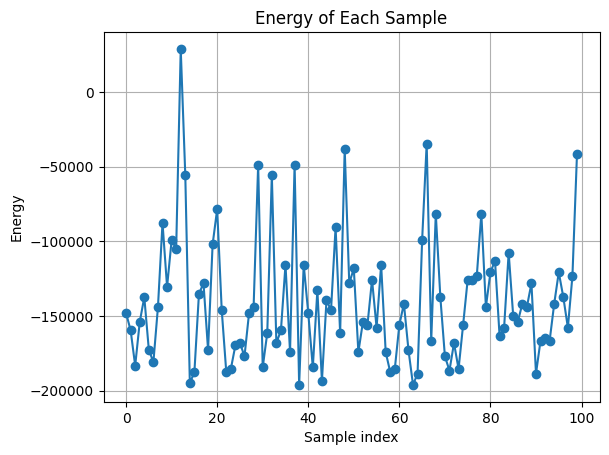

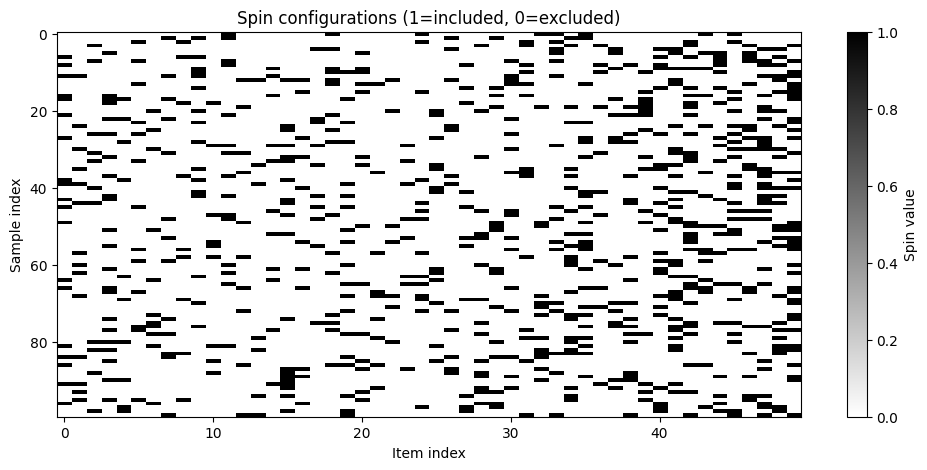

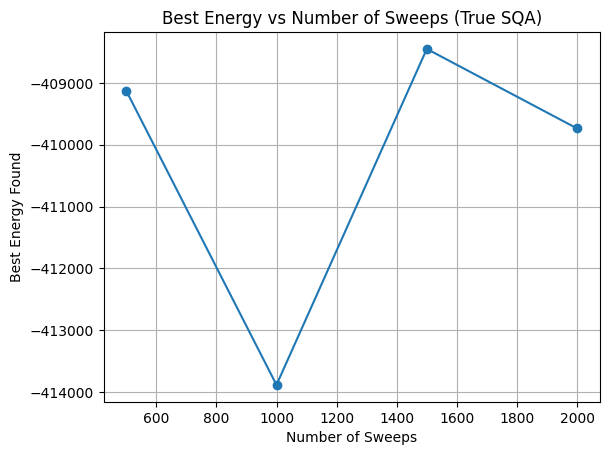

In [ ]:
# 1. Load packages
import numpy as np
import openjij as oj
import matplotlib.pyplot as plt
import dimod

# 2. Problem setup: 0/1 Knapsack
MAX_WEIGHT = 100
items_data = [
    ("Water Purifier", 25, 20), ("Solar Charger", 24, 19), ("Antibiotics", 27, 22), ("Compass", 21, 18), ("Map", 26, 21),
    ("Survival Knife", 22, 19), ("Two-way Radio", 28, 23), ("Flashlight", 25, 20), ("Lighter", 30, 25), ("Rope", 20, 17),
    ("First Aid Kit", 28, 24), ("Canned Food", 26, 22), ("High-Energy Compressed Biscuits", 25, 21), ("Waterproof Matches", 30, 26), ("Water Purification Tablets", 27, 23),
    ("Cold-Weather Clothing", 26, 22), ("Sleeping Bag", 24, 20), ("Tent", 28, 24), ("Protective Mask", 25, 21), ("Gas Mask", 23, 20),
    ("Ammunition", 29, 25), ("Firearm", 30, 26), ("Binoculars", 32, 28), ("Night Vision Goggles", 31, 27), ("Generator", 27, 23),
    ("Gasoline", 29, 25), ("Batteries", 30, 26), ("Shovel", 26, 22), ("Axe", 30, 26), ("Nails", 28, 24),
    ("Bandages", 20, 18), ("Disinfectant", 21, 19), ("Suture Kit", 23, 21), ("Painkillers", 19, 17), ("Vitamins", 22, 20),
    ("Fuel Oil", 18, 16), ("Stove", 24, 22), ("Tableware", 16, 15), ("Cookware", 17, 16), ("Raincoat", 23, 21),
    ("Salt", 17, 15), ("Sugar", 15, 14), ("Flour", 13, 12), ("Coffee Beans", 18, 17), ("Cigarettes", 16, 15),
    ("Alcohol", 15, 14), ("Atlas", 17, 16), ("Radio", 14, 13), ("Notebook", 12, 11), ("Pencil", 12, 11)
]
names   = [d[0] for d in items_data]
values  = np.array([d[1] for d in items_data])
weights = np.array([d[2] for d in items_data])
num_items = len(items_data)

# 3. Construct QUBO: H(x) = -Σ v_i x_i + λ(Σ w_i x_i - C)^2
penalty = 20
Q = {}
# Diagonal (linear) terms
for i in range(num_items):
    Q[(i, i)] = -values[i] + penalty * (weights[i]**2) - 2 * penalty * MAX_WEIGHT * weights[i]
# Interaction (quadratic) terms
for i in range(num_items):
    for j in range(i+1, num_items):
        Q[(i, j)] = 2 * penalty * weights[i] * weights[j]

# 4. Initialize SQA
sampler = oj.SQASampler()

# 5. Run sampling (num_sweeps controls the number of imaginary-time slices)
sampleset = sampler.sample_qubo(
    Q,
    num_reads=100,
    num_sweeps=2000,
)

# 6. Parse the best solution
best = sampleset.first.sample
selected = [i for i, x in best.items() if x == 1]
sel_names   = [names[i] for i in selected]
total_value = sum(values[i]  for i in selected)
total_weight= sum(weights[i] for i in selected)

print(" SQA (OpenJij) True Trotter SQA Solution:")
print(" Selected supplies:", sel_names)
print(f" Total value: {total_value}, Total weight: {total_weight}")

# 7. Heatmap: observe all sampled binary configurations
energies = sampleset.record.energy
plt.figure()
plt.plot(energies, marker='o')
plt.title("Energy of Each Sample")
plt.xlabel("Sample index")
plt.ylabel("Energy")
plt.grid(True)
plt.show()


plt.figure(figsize=(12,5))
plt.imshow(sampleset.record.sample, aspect='auto', cmap='binary')
plt.xlabel("Item index")
plt.ylabel("Sample index")
plt.title("Spin configurations (1=included, 0=excluded)")
plt.colorbar(label="Spin value")
plt.show()


# 8. Sweep Study: Best Energy vs Number of Sweeps (True SQA)
sweep_counts = [500, 1000, 1500, 2000]
best_energies = []

for sweeps in sweep_counts:
    ss = sampler.sample_ising(
        linear,        # h_i from step 3
        quadratic,     # J_{ij} from step 3
        num_reads=50,
        num_sweeps=sweeps
    )
    # If the true physical energy is desired, add the offset here:
    energy = ss.first.energy + offset
    best_energies.append(energy)

plt.figure()
plt.plot(sweep_counts, best_energies, marker='o')
plt.title("Best Energy vs Number of Sweeps (True SQA)")
plt.xlabel("Number of Sweeps")
plt.ylabel("Best Energy Found")
plt.grid(True)
plt.show()

1. Algorithm Comparison

Compare the supply combinations found by SA and SQA. Which method achieves a higher total survival value?

In terms of runtime, is there a significant difference between the two? Does this align with your professional understanding and expectations of these two algorithms (SA resembling thermal annealing, and SQA resembling quantum tunneling)?

2. Quantum Advantage of SQA

By observing the results of SQA, what special advantages do you think it has over traditional SA in problems where the value-to-weight ratio is not obvious?

Try adjusting the value of num_sweeps and observe how increasing or decreasing the number of imaginary-time slices affects the results and the runtime.